# Workshop 2
# Linear regression model building

From the dataset generated from WS1 we are going to build a linear regression model that estimates the price per m2 of the properties.

The model can be built involving only a subset of the clean dataset, with some particular characteristics. For example, only apartments in the Belgrano and Palermo neighborhoods or only PHs in the Almagro and Villa Crespo neighborhoods, or only industrial properties in Pompeya.

The dataset you use for your models must have at least 2000 rows.

## Objectives:
1. Select the data to model. Justify that selection.
2. Train at least three different linear regression models on this data.
3. Evaluate the performance of the models and compare the advantages and disadvantages of each one.
4. Determine the importance of the features included in the prediction.

## Requirements and material to deliver
1. A jupyter notebook/lab that meets the project requirements, where the cleaning and analysis of the data to be delivered is performed and displayed. The notebook must be properly commented, and must be able to run without errors from start to finish.
2. A presentation of no more than 10 minutes of the work done, consisting of a presentation accompanied by some non-technical slides (PPT or Google Slides).

This presentation must consist of:
- An introduction (statement of the problem, the question, the description of the dataset, etc.).
- A development of the analyzes carried out (descriptive analysis, preliminary correlation analysis, preliminary visualizations).
- An exposition of the main results and conclusions.

## Libraries to use

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Initial dataset exploration

#### Upload of the original file supplied.

In [2]:
data_original = pd.read_csv('properatti_clean.csv',index_col = 0)
data_original.head(3)

,property_type,place_name,place_with_parent_names,state_name,geonames_id,lat,lon,price,currency,price_aprox_local_currency,price_aprox_usd,surface_total_in_m2,surface_covered_in_m2,price_usd_per_m2,price_per_m2,floor,rooms,expenses,description,title
0,PH,Mataderos,|Argentina|Capital Federal|Mataderos|,Capital Federal,3430787.0,-34.661824,-58.508839,62000.0,USD,1093959.0,62000.0,55.0,40.0,1127.3,1550.0,NaN,NaN,NaN,"2 AMBIENTES TIPO CASA PLANTA BAJA POR PASILLO,...",2 AMB TIPO CASA SIN EXPENSAS EN PB
1,apartment,La Plata,|Argentina|Bs.As. G.B.A. Zona Sur|La Plata|,Bs.As. G.B.A. Zona Sur,3432039.0,-34.903883,-57.964330,150000.0,USD,2646675.0,150000.0,87.0,NaN,1723.2,NaN,NaN,NaN,NaN,Venta de departamento en décimo piso al frente...,VENTA Depto 2 dorm. a estrenar 7 e/ 36 y 37 ...
2,apartment,Mataderos,|Argentina|Capital Federal|Mataderos|,Capital Federal,3430787.0,-34.652262,-58.522982,72000.0,USD,1270404.0,72000.0,55.0,55.0,1309.1,1309.1,NaN,NaN,NaN,2 AMBIENTES 3ER PISO LATERAL LIVING COMEDOR AM...,2 AMB 3ER PISO CON ASCENSOR APTO CREDITO


#### Dataset statistical information.

In [3]:
data_original.describe()

,geonames_id,lat,lon,price,price_aprox_local_currency,price_aprox_usd,surface_total_in_m2,surface_covered_in_m2,price_usd_per_m2,price_per_m2,floor,rooms,expenses
count,9.384700e+04,64822.000000,64822.000000,9.459700e+04,9.459700e+04,1.111100e+05,111110.000000,93243.000000,111110.000000,8.223400e+04,7336.000000,43815.000000,1.362100e+04
mean,3.570363e+06,-34.661543,-59.225033,4.337855e+05,3.809328e+06,2.135782e+05,186.032192,128.105960,1861.236105,6.687183e+03,17.587514,3.043935,4.760178e+03
std,3.571437e+05,1.969916,2.266003,8.360021e+05,4.376376e+06,2.382572e+05,877.723966,728.426724,1645.175400,2.826776e+04,117.283152,1.787703,1.224923e+05
min,3.427208e+06,-54.819736,-75.678931,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,1.400000,1.500000e+00,1.000000,1.000000,1.000000e+00
25%,3.430234e+06,-34.677516,-58.713293,1.082660e+05,1.570360e+06,9.450000e+04,51.000000,45.000000,1132.100000,1.533300e+03,2.000000,2.000000,1.000000e+03
50%,3.433780e+06,-34.599116,-58.477368,1.800000e+05,2.470230e+06,1.430000e+05,85.000000,74.000000,1666.700000,2.187500e+03,3.000000,3.000000,1.900000e+03
75%,3.835793e+06,-34.450708,-58.393341,3.900000e+05,4.411125e+06,2.500000e+05,198.000000,150.000000,2236.800000,3.273350e+03,6.000000,4.000000,4.000000e+03
max,6.948895e+06,4.545843,-54.556127,1.000000e+08,2.293785e+08,1.300000e+07,154438.000000,187000.000000,35714.300000,4.000000e+06,2509.000000,32.000000,1.000150e+07


#### Amount of non-null data in the dataset.

In [4]:
data_original.notna().sum()

property_type                 111110
place_name                    111110
place_with_parent_names       111110
state_name                    111110
geonames_id                    93847
lat                            64822
lon                            64822
price                          94597
currency                       94596
price_aprox_local_currency     94597
price_aprox_usd               111110
surface_total_in_m2           111110
surface_covered_in_m2          93243
price_usd_per_m2              111110
price_per_m2                   82234
floor                           7336
rooms                          43815
expenses                       13621
description                   111108
title                         111110
dtype: int64

#### Amount of null data from the dataset.

In [5]:
data_original.isna().sum()

property_type                      0
place_name                         0
place_with_parent_names            0
state_name                         0
geonames_id                    17263
lat                            46288
lon                            46288
price                          16513
currency                       16514
price_aprox_local_currency     16513
price_aprox_usd                    0
surface_total_in_m2                0
surface_covered_in_m2          17867
price_usd_per_m2                   0
price_per_m2                   28876
floor                         103774
rooms                          67295
expenses                       97489
description                        2
title                              0
dtype: int64

#### Number of rows and columns contained in the dataset.

In [6]:
data_original.shape

(111110, 20)

#### Linear regression models will be developed using the 'state_name' variable with the largest amount of data.

In [7]:
data_original.state_name.value_counts()

Capital Federal                 29672
Bs.As. G.B.A. Zona Norte        23763
Bs.As. G.B.A. Zona Sur          13086
Córdoba                         10975
Buenos Aires Costa Atlántica     9641
Bs.As. G.B.A. Zona Oeste         8674
Santa Fe                         8570
Buenos Aires Interior            1884
Río Negro                         764
Tucumán                           610
Mendoza                           594
Corrientes                        562
Neuquén                           561
Misiones                          425
Entre Ríos                        333
Salta                             251
San Luis                          226
Chubut                            213
La Pampa                          130
Chaco                              53
Tierra Del Fuego                   30
Jujuy                              23
Formosa                            21
San Juan                           18
Santa Cruz                         16
Catamarca                           9
Santiago Del

#### Only properties where the 'state_name' is 'Federal Capital' are used.

In [8]:
mask_cf = data_original.state_name == 'Capital Federal'
data = data_original[mask_cf]

#### Only the columns that will be used for the models are kept.

In [9]:
data = data.filter(items = ['property_type','place_name','price_aprox_usd','surface_total_in_m2','price_usd_per_m2'], axis = 1)

#### Amount of rows and columns that make up the new data set to perform the regression models.

In [10]:
data.shape

(29672, 5)

#### Amount of null data form the data subset.

In [11]:
data.isna().sum()

property_type          0
place_name             0
price_aprox_usd        0
surface_total_in_m2    0
price_usd_per_m2       0
dtype: int64

#### The data subset indices are reset so as not to lose the consecutive order.

In [12]:
data.reset_index(inplace = True ,drop = True)

#### The data subset is exported so as not to carry out the data processing again.

In [13]:
data.to_csv('properatti_tp2.csv')

## Data Subset Correlation Plots

#### The distributions of the dataset variables are plotted.

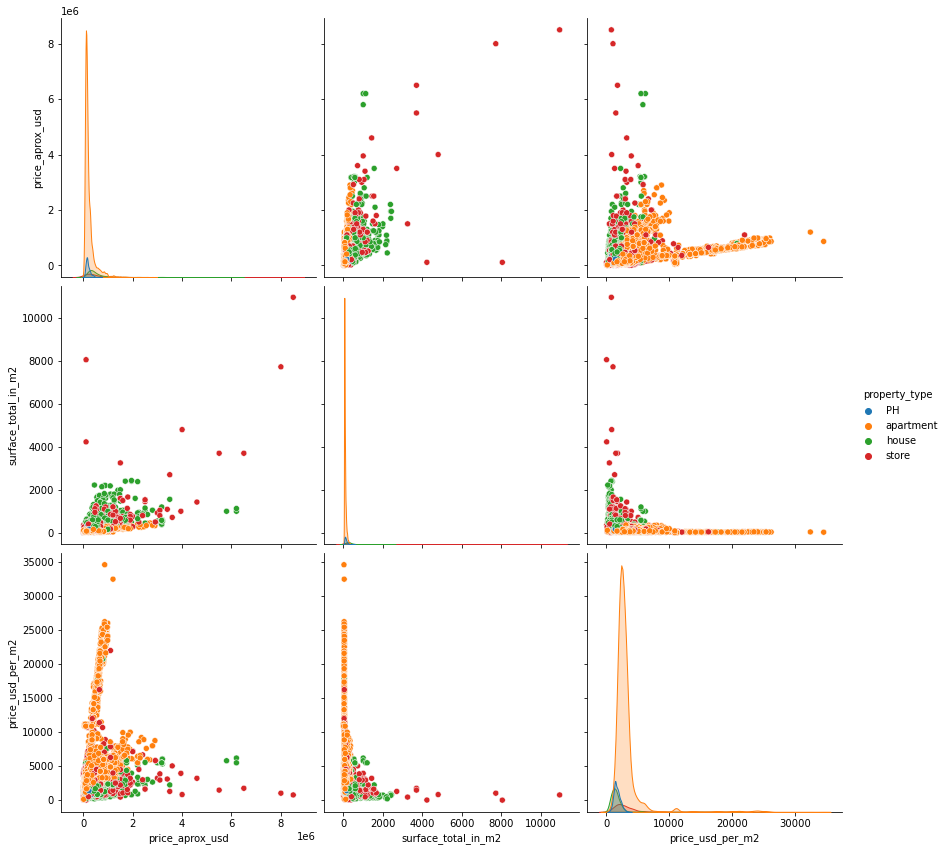

In [14]:
sns.pairplot(data, hue = 'property_type', height = 4)
plt.show()

#### The correlation matrix is plotted to numerically determine the relationship between the dataset variables.

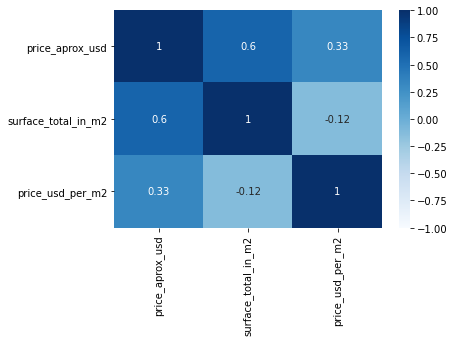

In [15]:
sns.heatmap(data.corr(), annot = True, vmin = -1, cmap = 'Blues')
plt.show()

#### Amount of data grouped by 'place_name' and 'property_type' variables.

In [16]:
groups = data.groupby(['place_name','property_type'])['price_aprox_usd'].count().sort_values(ascending = False)
groups.head(12)

place_name     property_type
Belgrano       apartment        2546
Palermo        apartment        2390
Caballito      apartment        1952
Recoleta       apartment        1363
Villa Urquiza  apartment        1252
San Telmo      apartment        1010
Barrio Norte   apartment        1005
Flores         apartment         994
Villa Crespo   apartment         993
Almagro        apartment         899
Boedo          apartment         742
Nuñez          apartment         595
Name: price_aprox_usd, dtype: int64

#### The correlations between the dataset variables where 'place_name' is 'Belgrano' and 'property_type' is 'apartment' are plotted.

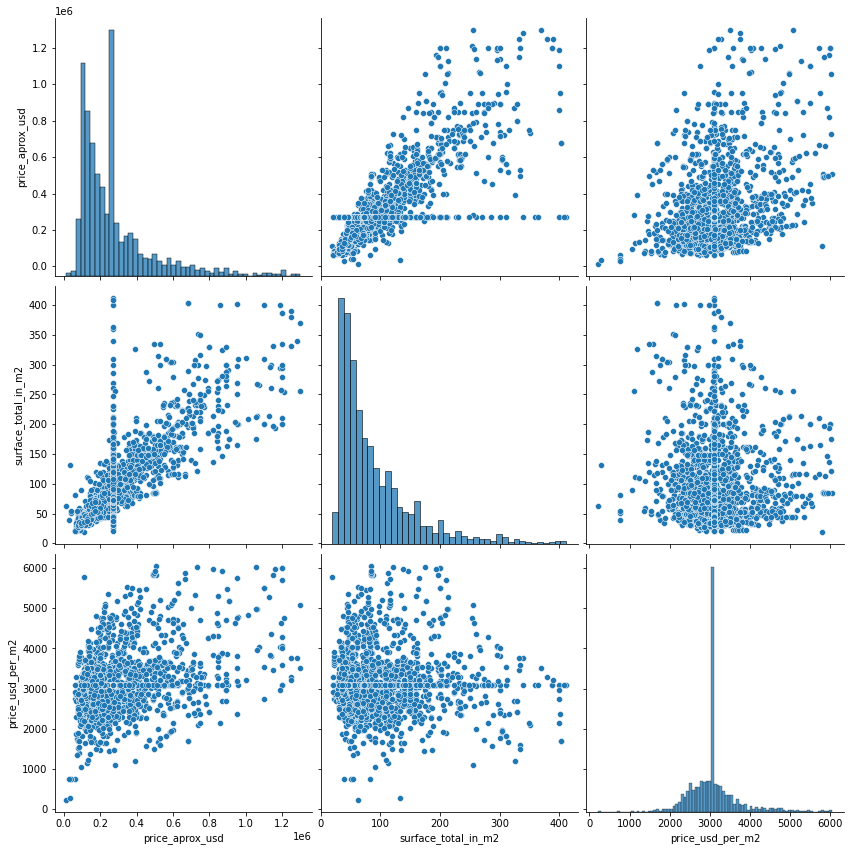

In [17]:
groups = data.groupby(['place_name','property_type'])
sns.pairplot(groups.get_group(('Belgrano', 'apartment')), height = 4)
plt.show()

#### Performing models under this grouping should generate lines that better represent the data group.

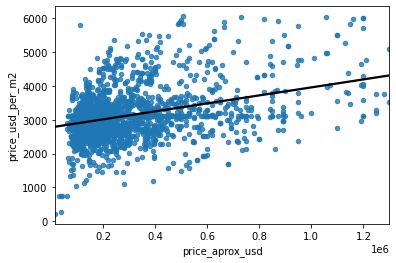

In [18]:
sns.regplot(data = groups.get_group(('Belgrano','apartment')), x = "price_aprox_usd", y = "price_usd_per_m2", order = 1, ci = None, scatter_kws = {'s' : 20}, line_kws = {'color': 'k'})
plt.show()

## Linear Regression Models

#### Model 1: Simple Linear Regression.
Variable X = 'price_aprox_usd' and Variable Y = 'price_usd_per_m2'.

The seven steps of the methodology to generate the model are applied.

#### 1. Select the model class.

In [19]:
from sklearn.linear_model import LinearRegression

#### 2. Choose the model's hyperparameters.

In [20]:
model_1 = LinearRegression(fit_intercept = True, normalize = True)

#### 3. Prepare the feature vector and the target vector.
Categorical columns that will not be used in this model are eliminated.

In [21]:
data_slr = data.drop(['place_name','property_type'], axis = 1, inplace = False)

#### The dataset is standardized with mean = 0 and standard deviation = 1.
The standardization result is verified.

In [22]:
scaler = StandardScaler()
scaler.fit(data_slr)
data_normalized = scaler.transform(data_slr)

print('Standardized means:', np.mean(data_normalized, axis = 0).round(2))
print('Standardized deviations:', np.std(data_normalized, axis = 0).round(2))

Standardized means: [ 0.  0. -0.]
Standardized deviations: [1. 1. 1.]


#### A data set is again created for processing without losing normalization.

In [23]:
data_normalized = pd.DataFrame(data_normalized, index = data_slr.index, columns = data_slr.columns)
data_normalized.describe().round(2)

,price_aprox_usd,surface_total_in_m2,price_usd_per_m2
count,29672.00,29672.00,29672.00
mean,0.00,0.00,-0.00
std,1.00,1.00,1.00
min,-0.87,-0.58,-1.11
25%,-0.50,-0.35,-0.36
50%,-0.32,-0.24,-0.17
75%,0.11,0.03,0.06
max,30.14,63.50,12.06


#### The data is separated into vectors.
The amount of data in the vectors is verified.

In [24]:
X = data_normalized[['price_aprox_usd']]
y = data_normalized.price_usd_per_m2

print("X length:", len(X))
print("y length:", len(y))

X length: 29672
y length: 29672


#### 4. Split the vectors into training and test data.

In [25]:
Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, random_state = 1)

#### 5. Fit the model to training data.

In [26]:
model_1.fit(Xtrain, ytrain)

LinearRegression(normalize=True)

In [27]:
model_1.coef_

array([0.35814085])

In [28]:
model_1.intercept_

0.003514635183813672

#### 6. Predict values for unknown data.

Applying the formula manually.

In [29]:
area_m2_test = 80
model_1.intercept_ + model_1.coef_ * area_m2_test

array([28.65478253])

Applying a method of the object.

In [30]:
test_sklearn = np.array(area_m2_test).reshape(-1,1)
model_1.predict(test_sklearn)

array([28.65478253])

In [31]:
ypred = model_1.predict(Xtest)
ypred

array([ 0.09983591,  0.21459955,  1.25307587, ..., -0.09378776,
       -0.21801305,  0.04351387])

#### 7. Evaluate the model's performance.

Model metrics.

In [32]:
print ('MAE:', mean_absolute_error(ytest, ypred).round(2))
print ('MSE:', mean_squared_error(ytest, ypred).round(2))
print ('RMSE:', np.sqrt(mean_squared_error(ytest, ypred)).round(2))
print ('R2:', r2_score(ytest, ypred).round(2))

MAE: 0.4
MSE: 0.89
RMSE: 0.94
R2: 0.09


Model prediction plot.

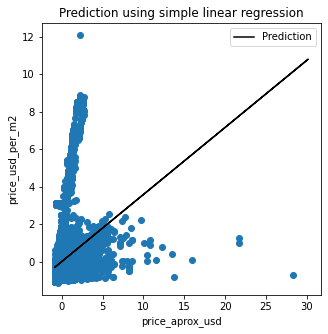

In [33]:
plt.figure(figsize = (5,5))
plt.plot(Xtest, ypred, color = "Black", label = "Prediction")
plt.scatter(Xtrain, ytrain)
plt.title("Prediction using simple linear regression")
plt.xlabel("price_aprox_usd")
plt.ylabel("price_usd_per_m2")
plt.legend()
plt.show()

#### Model 2: Multiple Linear Regression without categorical variables.
Variable X = ['price_aprox_usd' , 'surface_total_in_m2'] and Variable Y = 'price_usd_per_m2'.

The seven steps of the methodology to generate the model are applied.

#### 1. Select the model class.

In [34]:
from sklearn.linear_model import LinearRegression

#### 2. Choose the model's hyperparameters.

In [35]:
model_2 = LinearRegression(fit_intercept = True)

#### 3. Prepare the feature matrix and the target vector.
Categorical columns that will not be used in this model are eliminated.

In [36]:
data_mlr = data.drop(['place_name','property_type'], axis = 1, inplace = False)

#### The dataset is standardized with mean = 0 and standard deviation = 1.
The standardization result is verified.

In [37]:
scaler = StandardScaler()
scaler.fit(data_mlr)
data_normalized = scaler.transform(data_mlr)

print('Standardized means:', np.mean(data_normalized, axis = 0).round(2))
print('Standardized deviations:', np.std(data_normalized, axis = 0).round(2))

Standardized means: [ 0.  0. -0.]
Standardized deviations: [1. 1. 1.]


#### A data set is again created for processing without losing normalization.

In [38]:
data_normalized = pd.DataFrame(data_normalized, index = data_mlr.index, columns = data_mlr.columns)
data_normalized.describe().round(2)

,price_aprox_usd,surface_total_in_m2,price_usd_per_m2
count,29672.00,29672.00,29672.00
mean,0.00,0.00,-0.00
std,1.00,1.00,1.00
min,-0.87,-0.58,-1.11
25%,-0.50,-0.35,-0.36
50%,-0.32,-0.24,-0.17
75%,0.11,0.03,0.06
max,30.14,63.50,12.06


#### The data is separated into vectors.
The amount of data in the vectors is verified.

In [39]:
X = data_normalized[['price_aprox_usd','surface_total_in_m2']]
y = data_normalized.price_usd_per_m2

print("X length:", len(X))
print("y length:", len(y))

X length: 29672
y length: 29672


#### 4. Split the vectors into training and test data.

In [40]:
Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, random_state = 1)

#### 5. Fit the model to training data.

In [41]:
model_2.fit(Xtrain, ytrain)

LinearRegression()

In [42]:
model_2.coef_

array([ 0.63330438, -0.50653126])

In [43]:
model_2.intercept_

0.001943872268631744

#### 6. Predict values for unknown data.

In [44]:
ypred = model_2.predict(Xtest)
ypred

array([ 0.14988352,  0.32911852,  1.92251395, ..., -0.33768294,
       -0.20181002, -0.3645102 ])

#### 7. Evaluate the model's performance.

Model metrics.

In [45]:
print ('MAE:', mean_absolute_error(ytest, ypred).round(2))
print ('MSE:', mean_squared_error(ytest, ypred).round(2))
print ('RMSE:', np.sqrt(mean_squared_error(ytest, ypred)).round(2))
print ('R2:', r2_score(ytest, ypred).round(2))

MAE: 0.35
MSE: 0.71
RMSE: 0.84
R2: 0.27


Model prediction plot.

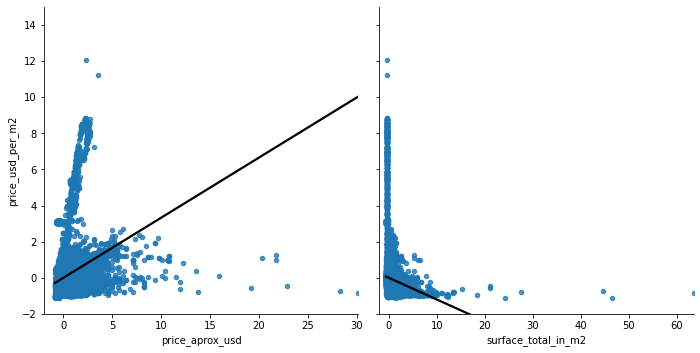

In [46]:
g = sns.PairGrid(data_normalized, y_vars = ['price_usd_per_m2'], x_vars = ['price_aprox_usd','surface_total_in_m2'], height = 5)
g.map(sns.regplot, ci = None, scatter_kws = {'s' : 20}, line_kws = {'color': 'k'})
g.axes[0,0].set_xlim(-2,)
g.axes[0,1].set_xlim(-2,)
plt.ylim(-2, 15)
plt.show()